In [1]:
using Piccolo
using LinearAlgebra
using CairoMakie
using Optim
using Random
using DifferentialEquations
Random.seed!(67)


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


TaskLocalRNG()

In [174]:
using LsqFit

In [81]:
const super_duper_value = 0.598144006661 # integral from -1/2 to 1/2 of e^(-8u^2)
λ = √2
DELTA = - 2π * 400 / 1000
u_bounds = [0.2, 0.2]

function gaussian_curve(T, N)
    A = π / (T * (super_duper_value - ℯ^(-2))) / 2
    μ = T / 2
    σ = T / 4

    times = collect(range(0, T, length = N))
    
    function f(t)
        return A * (ℯ^(-(t - μ)^2 / (2σ^2)) - ℯ^(-2))
    end

    function f_prime(t)
        return A * ℯ^(-(t - μ)^2 / (2σ^2)) * ((μ - t)/σ^2)
    end

    E_π = f.(times)
    Ė_π = f_prime.(times)

    clamp!(E_π, -u_bounds[1], u_bounds[1])
    clamp!(Ė_π, -u_bounds[2], u_bounds[2])

    return times, E_π, Ė_π
end

function drag_gaussian(T, N)
    times, E_π, Ė_π = gaussian_curve(T, N)
    E_x = E_π .+ ((λ^2-4)/(8DELTA^2) * E_π .^ 3) - ((13λ^4 - 76λ^2 + 112) / 128DELTA^4 * E_π .^ 5)
    E_y = -Ė_π ./ DELTA + ((33(λ^2-2)/24DELTA^3) * E_π .^2 .* Ė_π)
    return times, E_x, E_y
end

drag_gaussian (generic function with 1 method)

In [105]:
σ_ = ComplexF64[0 1; 0 0]
σx = ComplexF64[0 1; 1 0]
σy = ComplexF64[0 im; -im 0]
σz = ComplexF64[1 0; 0 -1]

function Commutator(H, ρ)
    return H * ρ - ρ * H
end

function Anti_Commutator(H, ρ)
    return H * ρ + ρ * H
end

function inner_D(ρ, σ)
    return σ * ρ * σ' - 0.5 * Anti_Commutator(σ' * σ, ρ)
end

function D_1(ρ, T1::Real, σ)
    return 1/T1 * inner_D(ρ, σ)
end

function D_ϕ(ρ, Tϕ::Real, σ)
    return 1/(2* Tϕ) * inner_D(ρ, σ)
end

D_ϕ (generic function with 1 method)

In [120]:
N = 100
T1 = 200
T2 = 150
Tϕ = 1 / (1 / T2 - 1 / 2T1)
noise = 0.01


function Uhlmann_Fidelity(ρ_target, ρ_final)
    real((tr(sqrt(sqrt(ρ_target) * ρ_final * sqrt(ρ_target))))^2)
end

function test_fidelity(controls, T)

    controls .+= noise * randn(2, N)
    Δt = T / (N - 1)

    function lindblad!(ρ̇, ρ, dt, t)
        idx = Int(floor(t / dt)) % size(controls)[2] + 1
        H_drive = controls[1, idx] * σx + controls[2, idx] * σy + D_1(ρ, T1, σ_) + D_ϕ(ρ, Tϕ, σz)
        ρ̇ .= -im * Commutator(H_drive,ρ) 
    end

    v_0 = ComplexF64[1; 0]
    ρ_0 = v_0 * v_0'

    v_f = ComplexF64[0; 1]
    ρ_f = v_f * v_f'

    prob = ODEProblem(lindblad!, ρ_0, (0, T), Δt)
    result = DifferentialEquations.solve(prob, Tsit5())
    return Uhlmann_Fidelity(ρ_f, result.u[end])
end


function test_gaussian(T)
    controls = zeros(2, N)
    times, gaussian, _ = gaussian_curve(T, N)
    controls[1, :] .= gaussian
    return test_fidelity(controls, T)
end

test_gaussian (generic function with 1 method)

In [165]:
Ts_start = 1
stop = 100
Ts_step = 1
Ts = range(Ts_start, stop, step = Ts_step)
gaussian_fidelities = zeros(length(Ts))
for (i, t_g) in enumerate(Ts)
    gaussian_fidelities[i] = abs.(1 .- test_gaussian(t_g))
end

In [166]:
function min_checker(lst)
    for i in range(1,size(lst,1))
        if lst[i]== minimum(lst)
            return [(i), lst[i]]
        end
    end
end


min_checker (generic function with 1 method)

In [171]:
function trendline(lst, step_size)
    avg = []
    for i in range(1, size(lst)[1]; step = step_size)
        push!(avg, sum(lst[i:(i+step_size-1)])/step_size)
    end
    return avg
end
step_size = 5
new_Ts =  range(Ts_start/step_size, Integer(floor(stop/step_size)), step = Ts_step/step_size)


0.2:0.2:20.0

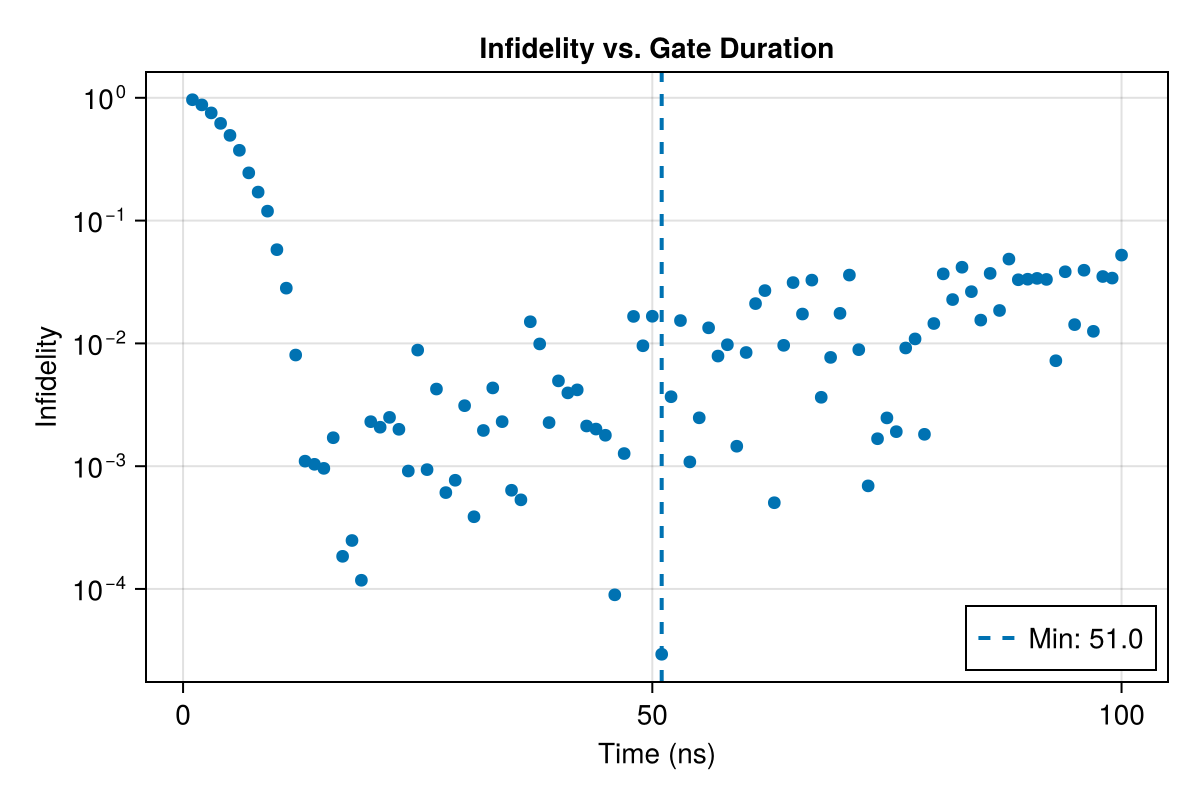

In [209]:
fig = Figure(size = (600, 400))
ax = Axis(fig[1,1], title = "Infidelity vs. Gate Duration", xlabel = "Time (ns)", ylabel = "Infidelity", yscale = log10)
CairoMakie.scatter!(ax, Ts, gaussian_fidelities)
vlines!(ax, min_checker(gaussian_fidelities)[1], linewidth = 2, linestyle = :dash, label = "Min: $(min_checker(gaussian_fidelities)[1])")
axislegend(ax, position = :rb)
fig

In [211]:
using Plots

Plots.scatter(Ts, gaussian_fidelities, yscale = :log10, label = "Gaussian Pulse",title = "Infidelity vs. Gate Duration", xlabel = "Time (ns)", ylabel = "Infidelity")


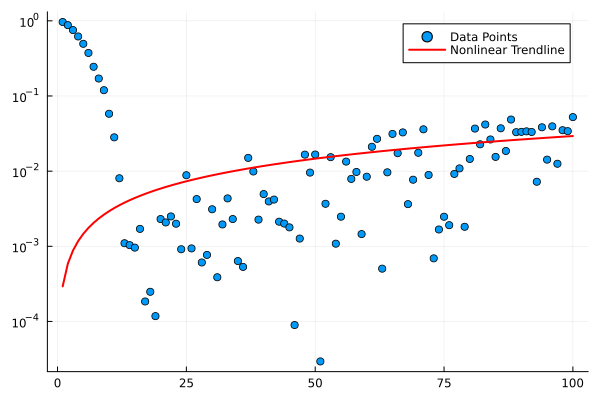

In [188]:

x = Ts
y = gaussian_fidelities

# 2. Define a nonlinear model (e.g., exponential decay: y = p[1] * exp(-p[2] * x))
@. model(x, p) = p[1] * (-p[2] * x)

# 3. Initial parameter guesses [p1, p2]
p0 = [1.0, 0.1]

# 4. Perform the curve fit
fit = curve_fit(model, x, y, p0)
parameters = fit.param

# 5. Generate smooth x values for the trendline
x_smooth = range(minimum(x), maximum(x), length=100)
y_smooth = model(x_smooth, parameters)

# 6. Plot the scatter data and overlay the trendline
Plots.scatter(x, y, label="Data Points", legend=:topright, yscale = :log10 )
Plots.plot!(x_smooth, y_smooth, label="Nonlinear Trendline", lw=2, color=:red)
